In [ ]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "01_fund_master.csv":
            print(os.path.join(root, file))

/content/drive/MyDrive/Bluestock_MF_Capstone/data/raw/01_fund_master.csv
/content/drive/MyDrive/Bluestock_MF_Capstone/data/cleaned/01_fund_master.csv


In [ ]:
# Load cleaned datasets

fund_master = pd.read_csv("/content/drive/MyDrive/Bluestock_MF_Capstone/data/cleaned/01_fund_master.csv")

nav_history = pd.read_csv("/content/drive/MyDrive/Bluestock_MF_Capstone/data/cleaned/02_nav_history.csv")

performance = pd.read_csv("/content/drive/MyDrive/Bluestock_MF_Capstone/data/cleaned/07_scheme_performance.csv")

In [ ]:
base_path = "/content/drive/MyDrive/Bluestock_MF_Capstone/data/cleaned/"

In [ ]:
fund_master = pd.read_csv(base_path + "01_fund_master.csv")
nav_history = pd.read_csv(base_path + "02_nav_history.csv")
aum = pd.read_csv(base_path + "03_aum_by_fund_house.csv")
sip = pd.read_csv(base_path + "04_monthly_sip_inflows.csv")
category = pd.read_csv(base_path + "05_category_inflows.csv")
folio = pd.read_csv(base_path + "06_industry_folio_count.csv")
performance = pd.read_csv(base_path + "07_scheme_performance.csv")
transactions = pd.read_csv(base_path + "08_investor_transactions.csv")
portfolio = pd.read_csv(base_path + "09_portfolio_holdings.csv")
benchmark = pd.read_csv(base_path + "10_benchmark_indices.csv")

In [ ]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:<15} : {df.shape}")

Fund Master     : (40, 15)
NAV History     : (46000, 3)
AUM             : (90, 5)
SIP             : (48, 6)
Category        : (144, 3)
Folio           : (21, 6)
Performance     : (40, 19)
Transactions    : (32778, 13)
Portfolio       : (322, 8)
Benchmark       : (8050, 3)


In [ ]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [ ]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ra

In [ ]:
performance.describe()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


In [ ]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

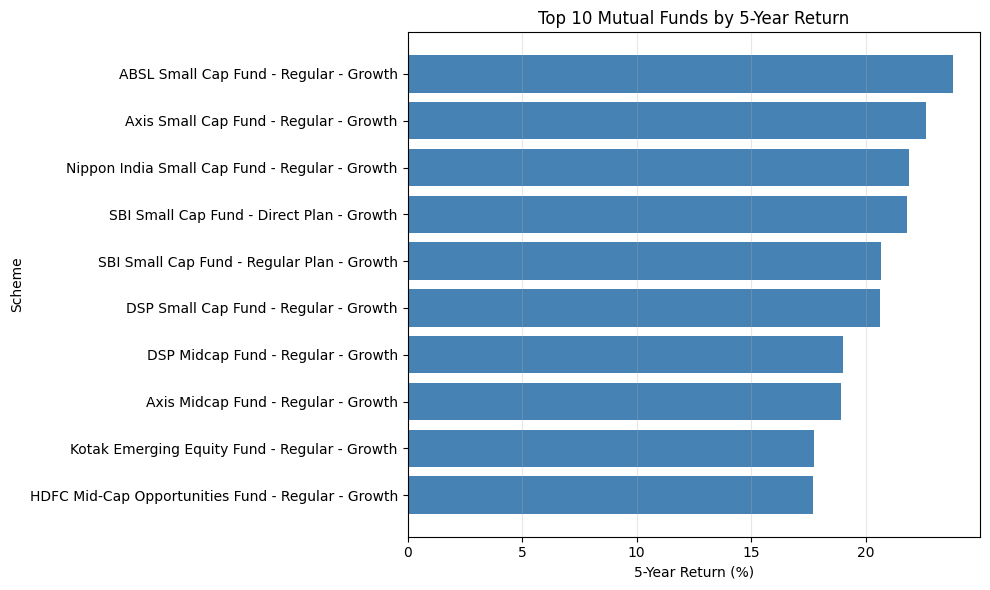

In [ ]:
top10 = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["scheme_name"],
    top10["return_5yr_pct"],
    color="steelblue"
)

plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Funds by 5-Year Return")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Observation:

• Small Cap funds dominate the top 10 highest-performing mutual funds based on 5-year returns.

• ABSL Small Cap Fund - Regular - Growth delivered the highest 5-year return.

• Most top-performing schemes generated returns above 18%, indicating strong long-term equity performance.

• Mid Cap funds also secured positions among the top performers, reflecting consistent long-term growth potential.

Business Insight:

Investors seeking long-term wealth creation may consider high-performing Small Cap and Mid Cap funds. Asset Management Companies (AMCs) can use these consistently top-performing schemes in marketing campaigns, while investment advisors can recommend them to long-term investors with higher risk tolerance.

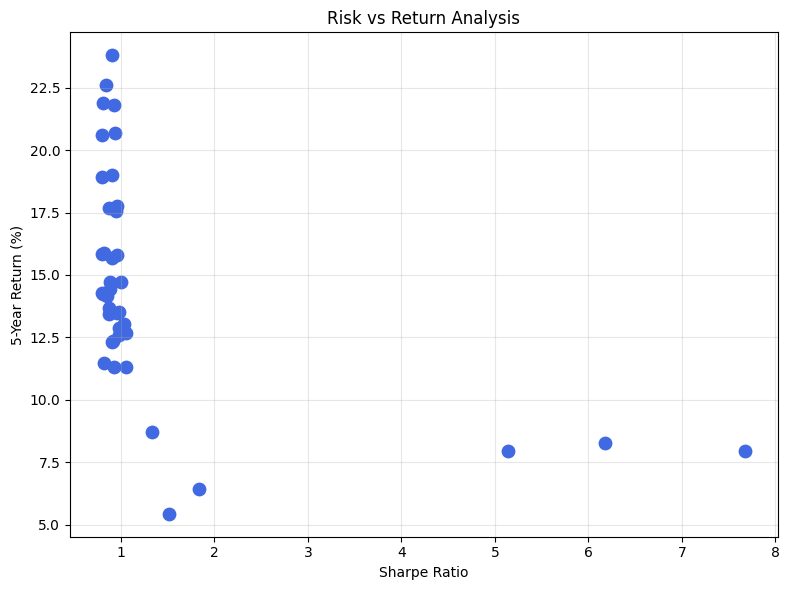

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    performance["sharpe_ratio"],
    performance["return_5yr_pct"],
    s=80,
    color="royalblue"
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("5-Year Return (%)")
plt.title("Risk vs Return Analysis")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Observation:

• Most mutual funds are clustered around a Sharpe Ratio of 0.8–1.2, indicating similar risk-adjusted performance.

• Several funds achieved higher 5-year returns while maintaining moderate Sharpe Ratios, suggesting efficient risk management.

• A few outlier funds exhibit unusually high Sharpe Ratios but comparatively lower returns.

• Overall, higher Sharpe Ratios generally indicate better risk-adjusted investment performance.

Business Insight:

Risk-adjusted performance is as important as absolute returns while selecting mutual funds. Investors should prioritize funds that offer a balanced combination of higher returns and strong Sharpe Ratios instead of choosing schemes based solely on returns. This approach supports more consistent long-term portfolio performance.

This scatter plot compares each mutual fund's 5-year return with its Sharpe Ratio. Funds positioned higher on the chart generated better long-term returns, while those with higher Sharpe Ratios delivered superior risk-adjusted performance. The analysis helps identify funds that provide an optimal balance between risk and return.

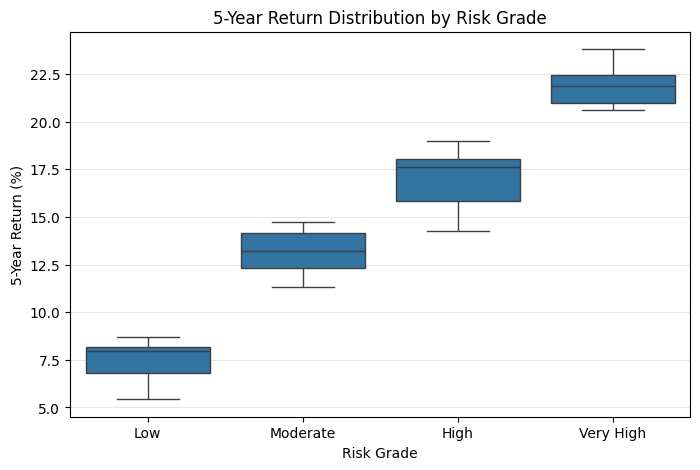

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=performance,
    x="risk_grade",
    y="return_5yr_pct",
    order=["Low","Moderate","High","Very High"]
)

plt.title("5-Year Return Distribution by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("5-Year Return (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

Observation:

• Funds categorized under High and Very High risk generally delivered higher 5-year returns.
• Low-risk funds showed relatively stable but lower return distributions.
• Moderate-risk funds provided balanced performance with less variation.
• Return variability increased with higher risk grades, reflecting the classic risk-return tradeoff.

Business Insight:

The analysis confirms that higher-risk mutual funds have greater potential to generate superior long-term returns, although they also exhibit higher performance variability. Investors should select funds based on their individual risk appetite and investment horizon rather than focusing only on maximum returns.

This box plot compares the distribution of 5-year returns across different risk grades. It highlights the median return, spread, and outliers for each category, helping investors understand how risk level influences long-term performance.

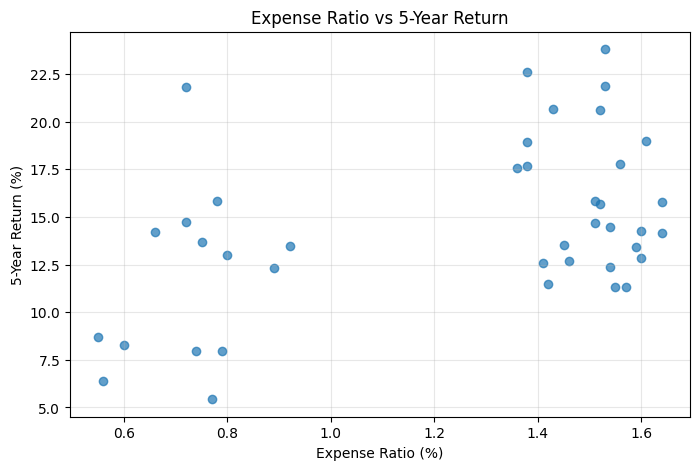

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    performance["expense_ratio_pct"],
    performance["return_5yr_pct"],
    alpha=0.7
)

plt.title("Expense Ratio vs 5-Year Return")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("5-Year Return (%)")

plt.grid(alpha=0.3)

plt.show()

Observation:

• No strong linear relationship is observed between expense ratio and 5-year returns.
• Several funds with moderate expense ratios generated competitive long-term returns.
• Some high-expense funds failed to outperform lower-cost alternatives.
• Fund performance appears to depend on multiple factors beyond expense ratio alone.

Business Insight:

A higher expense ratio does not necessarily guarantee superior investment performance. Investors should evaluate long-term returns, risk measures, and portfolio quality together instead of selecting funds solely based on management fees.

This scatter plot evaluates whether mutual funds charging higher management fees consistently deliver better long-term returns. The analysis indicates that expense ratio alone is not a reliable predictor of fund performance.

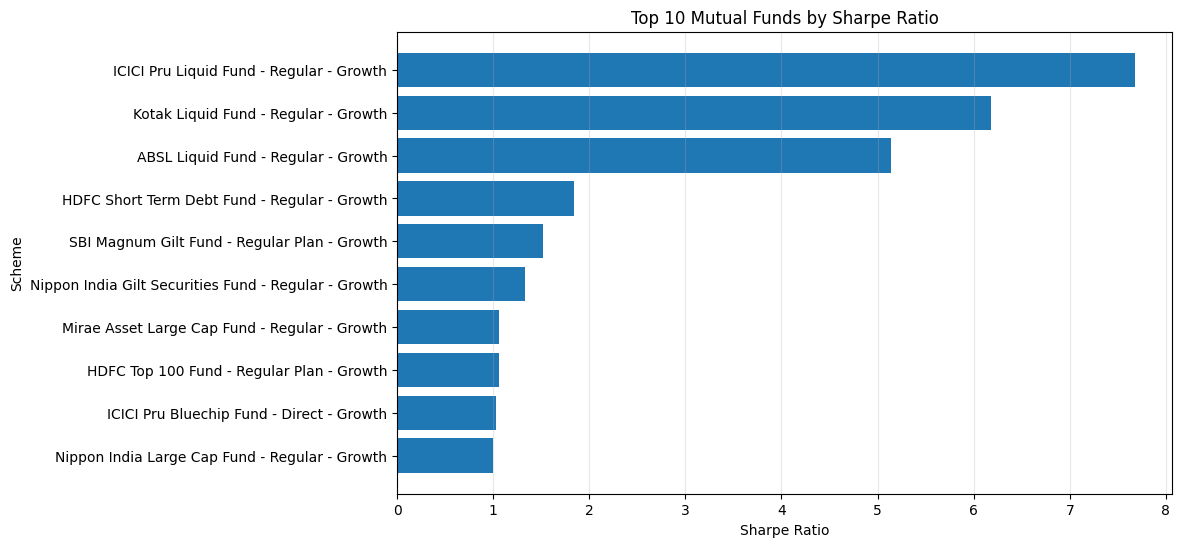

In [ ]:
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.title("Top 10 Mutual Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

Observation:

• The top-ranked funds exhibit significantly higher Sharpe Ratios, indicating superior risk-adjusted performance.
• These funds generated higher returns while maintaining comparatively lower volatility.
• Most funds have Sharpe Ratios clustered around moderate values, while only a few outperform substantially.
• High Sharpe Ratio funds represent more efficient investment opportunities from a risk-return perspective.

Business Insight:

Sharpe Ratio is one of the most important metrics for evaluating mutual fund efficiency. Investors seeking better risk-adjusted returns should prioritize funds with consistently higher Sharpe Ratios rather than focusing only on absolute returns.

This chart ranks mutual funds based on their Sharpe Ratio, which measures excess return generated for each unit of risk taken. A higher Sharpe Ratio indicates a more efficient and attractive investment from a portfolio management perspective.

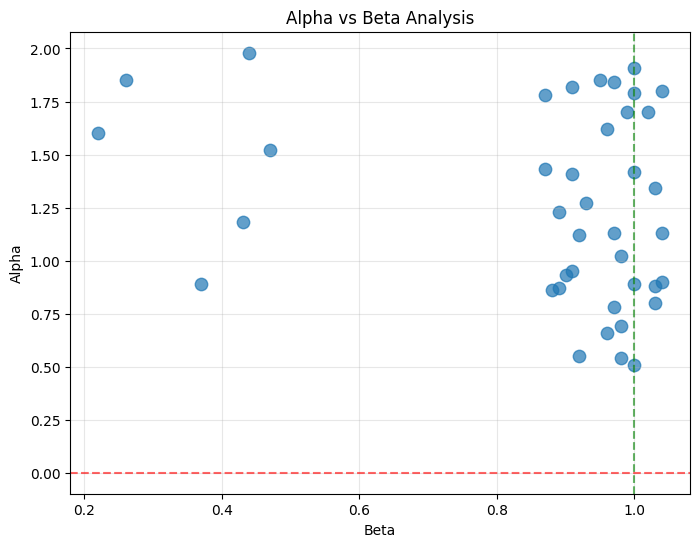

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    performance["beta"],
    performance["alpha"],
    s=80,
    alpha=0.7
)

plt.axhline(0, color="red", linestyle="--", alpha=0.6)
plt.axvline(1, color="green", linestyle="--", alpha=0.6)

plt.title("Alpha vs Beta Analysis")
plt.xlabel("Beta")
plt.ylabel("Alpha")

plt.grid(alpha=0.3)

plt.show()

Observation:

• Most mutual funds have Beta values close to 1, indicating market-like volatility.
• Several funds exhibit positive Alpha, demonstrating performance above their benchmark.
• A few funds combine low Beta with positive Alpha, representing efficient investment choices.
• Funds with negative or near-zero Alpha indicate limited excess returns over the benchmark.

Business Insight:

Funds delivering positive Alpha while maintaining Beta close to or below 1 are generally more attractive for long-term investors, as they generate superior returns without taking excessive market risk.

This scatter plot compares Alpha and Beta for each mutual fund. Alpha measures excess return over the benchmark, while Beta indicates sensitivity to market movements. Funds with positive Alpha and moderate Beta are generally considered better investment opportunities.

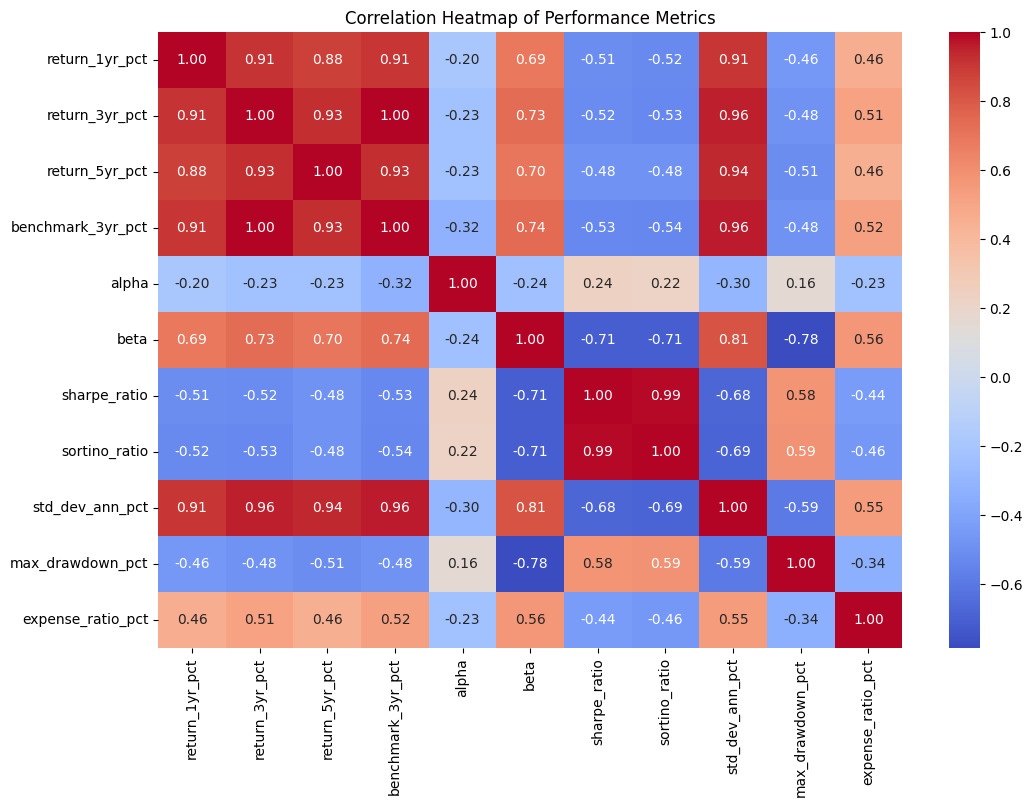

In [ ]:
corr_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "benchmark_3yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "sortino_ratio",
    "std_dev_ann_pct",
    "max_drawdown_pct",
    "expense_ratio_pct"
]

plt.figure(figsize=(12,8))

sns.heatmap(
    performance[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Performance Metrics")

plt.show()

Observation:

• Strong positive correlations exist among 1-year, 3-year, and 5-year returns, indicating consistent long-term performance trends.
• Sharpe Ratio and Sortino Ratio exhibit a strong positive relationship, as both measure risk-adjusted returns.
• Standard deviation shows a positive association with Beta, suggesting higher market risk leads to greater volatility.
• Expense Ratio has a weak correlation with returns, indicating that higher management fees do not necessarily improve fund performance.
• Maximum Drawdown displays a negative relationship with returns, reflecting the adverse impact of larger losses on long-term performance.

Business Insight:

The correlation analysis helps identify which performance metrics move together. Investors and fund managers can use these relationships to select meaningful KPIs, avoid redundant metrics, and make more informed portfolio evaluation and investment decisions.

This heatmap visualizes the correlation among key mutual fund performance metrics. It helps identify positive and negative relationships between returns, risk measures, and fund characteristics, enabling deeper analytical insights into portfolio performance.

In [ ]:
# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort data
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

In [ ]:
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [ ]:
nav_history.head(15)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [ ]:
nav_history["daily_return"].describe()

,daily_return
count,45960.000000
mean,0.000631
std,0.010290
min,-0.058102
25%,-0.005042
50%,0.000340
75%,0.006324
max,0.064713


Observation:

• Daily returns were successfully calculated for each mutual fund using percentage change in NAV.
• The first observation for every scheme contains a missing value because no previous NAV exists for comparison.
• Most daily returns are close to zero, indicating that mutual fund NAVs generally change gradually from day to day.
• Daily return data will serve as the foundation for all subsequent risk and performance metrics.

Business Insight:

Daily returns provide the fundamental building block for performance analysis. Metrics such as volatility, Sharpe Ratio, Sortino Ratio, Value at Risk (VaR), and Maximum Drawdown are all derived from daily return series rather than raw NAV values.

Daily Return measures the percentage change in a mutual fund's NAV from one trading day to the next. It is the most basic performance metric and serves as the foundation for advanced financial analytics such as volatility, Sharpe Ratio, Beta, and Value at Risk.

In [ ]:
annual_return = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .mean()
)

annual_return = ((1 + annual_return) ** 252 - 1) * 100

annual_return = annual_return.reset_index()
annual_return.columns = ["amfi_code", "annualized_return_pct"]

annual_return.head()

,amfi_code,annualized_return_pct
0,100016,3.632469
1,100025,4.378122
2,100033,31.253944
3,101206,23.931060
4,101207,11.286684


In [ ]:
annual_return = annual_return.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

annual_return.head()

,amfi_code,annualized_return_pct,scheme_name
0,100016,3.632469,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.378122,HDFC Short Term Debt Fund - Regular - Growth
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth
4,101207,11.286684,ABSL Small Cap Fund - Regular - Growth


In [ ]:
top10_annual = annual_return.sort_values(
    "annualized_return_pct",
    ascending=False
).head(10)

top10_annual

,amfi_code,annualized_return_pct,scheme_name
21,119598,35.320299,SBI Small Cap Fund - Regular Plan - Growth
39,149324,35.087387,DSP Small Cap Fund - Regular - Growth
25,120505,33.974986,ICICI Pru Midcap Fund - Regular - Growth
36,148569,32.724124,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,31.318423,Kotak Flexicap Fund - Regular - Growth
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,31.051613,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,30.443234,DSP Midcap Fund - Regular - Growth
16,119094,29.510935,Axis Midcap Fund - Regular - Growth
19,119551,25.976767,SBI Bluechip Fund - Regular Plan - Growth


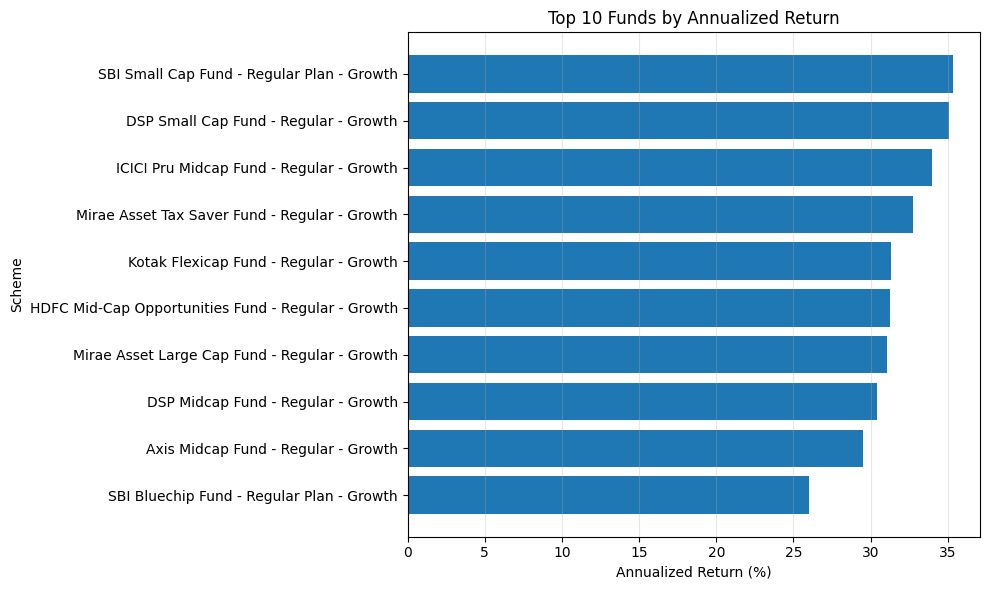

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_annual["scheme_name"],
    top10_annual["annualized_return_pct"]
)

plt.title("Top 10 Funds by Annualized Return")

plt.xlabel("Annualized Return (%)")
plt.ylabel("Scheme")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

Observation:

• Annualized returns were calculated from daily returns using the standard 252-trading-day assumption.
• The highest-ranked funds generated substantially higher annualized returns than the remaining schemes.
• Equity-oriented funds generally outperformed debt-oriented funds on an annualized basis.
• Annualized Return provides a standardized measure for comparing funds over different holding periods.

Business Insight:

Annualized Return allows investors to compare mutual fund performance on a consistent yearly basis, regardless of the investment period. It is widely used for benchmarking, fund ranking, and portfolio performance evaluation.

Annualized Return converts average daily returns into an equivalent yearly return using the assumption of 252 trading days. It provides a standardized metric for comparing the long-term performance of different mutual funds.

In [ ]:
cagr_df = (
    nav_history
    .sort_values("date")
    .groupby("amfi_code")
    .agg(
        start_nav=("nav","first"),
        end_nav=("nav","last"),
        start_date=("date","first"),
        end_date=("date","last")
    )
    .reset_index()
)

cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date
0,100016,520.4608,583.6113,2022-01-03,2026-05-29
1,100025,26.3169,31.8843,2022-01-03,2026-05-29
2,100033,107.3758,342.0072,2022-01-03,2026-05-29
3,101206,305.0996,773.2939,2022-01-03,2026-05-29
4,101207,38.5736,53.9836,2022-01-03,2026-05-29


In [ ]:
cagr_df["years"] = (
    cagr_df["end_date"] -
    cagr_df["start_date"]
).dt.days / 365.25

In [ ]:
cagr_df["cagr_pct"] = (
    (
        cagr_df["end_nav"] /
        cagr_df["start_nav"]
    ) ** (1 / cagr_df["years"]) - 1
) * 100

In [ ]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr_pct,scheme_name
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,2.637074,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,4.458210,HDFC Short Term Debt Fund - Regular - Growth
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,23.538361,ABSL Frontline Equity Fund - Regular - Growth
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,7.938765,ABSL Small Cap Fund - Regular - Growth


In [ ]:
top10_cagr = (
    cagr_df
    .sort_values(
        "cagr_pct",
        ascending=False
    )
    .head(10)
)

top10_cagr

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr_pct,scheme_name
25,120505,135.8720,473.7640,2022-01-03,2026-05-29,4.399726,32.827406,ICICI Pru Midcap Fund - Regular - Growth
21,119598,89.8738,309.2050,2022-01-03,2026-05-29,4.399726,32.423536,SBI Small Cap Fund - Regular Plan - Growth
39,149324,81.6814,279.7511,2022-01-03,2026-05-29,4.399726,32.287440,DSP Small Cap Fund - Regular - Growth
36,148569,28.8620,97.7435,2022-01-03,2026-05-29,4.399726,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,70.2514,230.2708,2022-01-03,2026-05-29,4.399726,30.974108,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,49.9131,163.2397,2022-01-03,2026-05-29,4.399726,30.907455,Kotak Flexicap Fund - Regular - Growth
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,78.4622,245.3651,2022-01-03,2026-05-29,4.399726,29.581087,DSP Midcap Fund - Regular - Growth
16,119094,68.3023,203.8581,2022-01-03,2026-05-29,4.399726,28.214417,Axis Midcap Fund - Regular - Growth
19,119551,54.3856,149.3216,2022-01-03,2026-05-29,4.399726,25.804686,SBI Bluechip Fund - Regular Plan - Growth


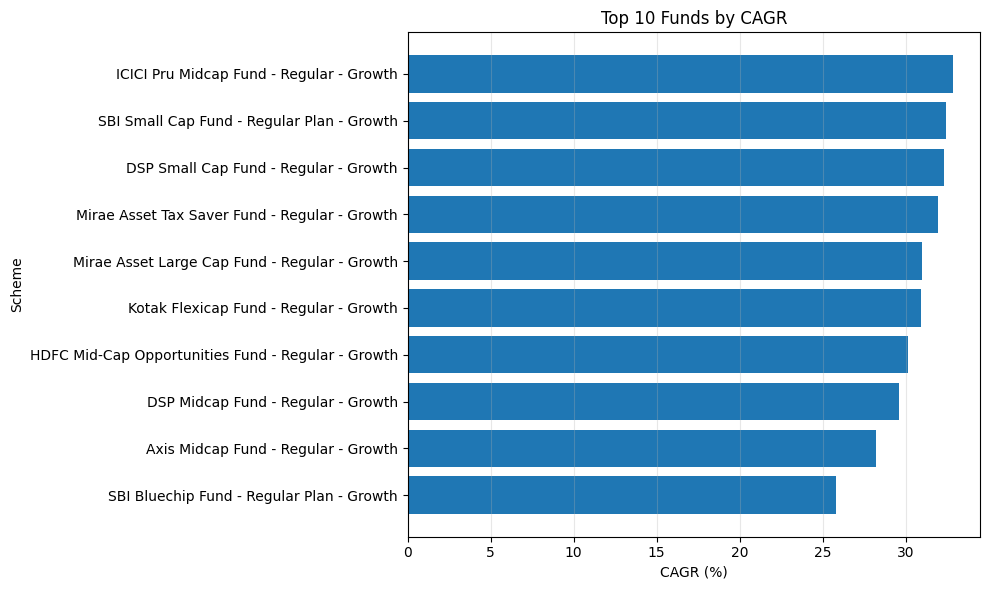

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_cagr["scheme_name"],
    top10_cagr["cagr_pct"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds by CAGR")

plt.xlabel("CAGR (%)")
plt.ylabel("Scheme")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

Observation:

• CAGR was calculated using the beginning and ending NAV values over the complete investment period.
• Funds with higher CAGR demonstrated stronger and more consistent long-term growth.
• Equity-oriented schemes achieved higher CAGR values compared to conservative debt-oriented funds.
• CAGR provides a better measure of long-term performance than simple average returns because it accounts for compounding.

Business Insight:

CAGR is one of the most widely used metrics for evaluating long-term mutual fund performance. Investors should compare CAGR across similar fund categories to identify consistently growing investment opportunities while considering associated risk levels.

CAGR measures the annualized growth rate of an investment assuming steady compounding over time. Unlike average return, CAGR considers the effect of compounding and provides a more accurate representation of long-term investment performance.

In [ ]:
volatility_df = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .std()
    * np.sqrt(252)
    * 100
)

volatility_df = volatility_df.reset_index()
volatility_df.columns = ["amfi_code", "volatility_pct"]

volatility_df.head()

,amfi_code,volatility_pct
0,100016,14.548135
1,100025,3.905246
2,100033,18.936711
3,101206,14.568213
4,101207,25.797322


In [ ]:
volatility_df = volatility_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

volatility_df.head()

,amfi_code,volatility_pct,scheme_name
0,100016,14.548135,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,3.905246,HDFC Short Term Debt Fund - Regular - Growth
2,100033,18.936711,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,14.568213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,25.797322,ABSL Small Cap Fund - Regular - Growth


In [ ]:
top10_vol = (
    volatility_df
    .sort_values("volatility_pct", ascending=False)
    .head(10)
)

top10_vol

,amfi_code,volatility_pct,scheme_name
4,101207,25.797322,ABSL Small Cap Fund - Regular - Growth
11,118634,25.241521,Nippon India Small Cap Fund - Regular - Growth
21,119598,25.140579,SBI Small Cap Fund - Regular Plan - Growth
17,119095,25.066580,Axis Small Cap Fund - Regular - Growth
22,119599,24.950125,SBI Small Cap Fund - Direct Plan - Growth
39,149324,24.840205,DSP Small Cap Fund - Regular - Growth
16,119094,19.407117,Axis Midcap Fund - Regular - Growth
25,120505,19.290949,ICICI Pru Midcap Fund - Regular - Growth
2,100033,18.936711,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
33,125498,18.352430,HDFC Mid-Cap Opportunities Fund - Direct - Growth


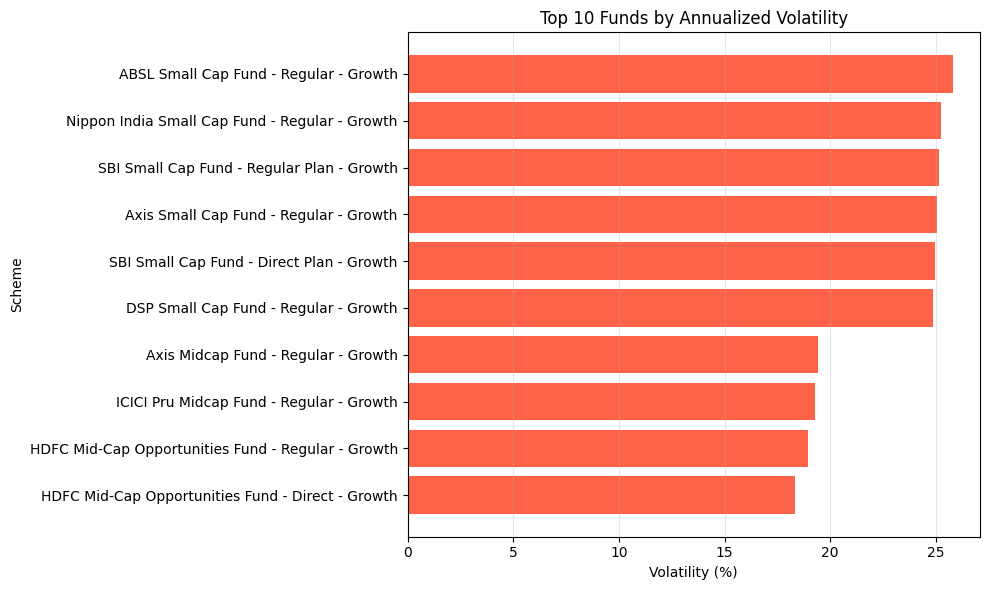

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_vol["scheme_name"],
    top10_vol["volatility_pct"],
    color="tomato"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds by Annualized Volatility")
plt.xlabel("Volatility (%)")
plt.ylabel("Scheme")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

Observation:

• Annualized volatility was calculated using the standard deviation of daily returns.
• Funds with higher volatility experienced larger fluctuations in NAV, indicating greater investment risk.
• Small Cap and Mid Cap funds generally showed higher volatility than debt-oriented funds.
• Volatility is an essential measure of investment risk and should always be interpreted alongside returns.

Business Insight:

Volatility helps investors understand the level of risk associated with each mutual fund. While high-volatility funds may offer higher return potential, they are also more sensitive to market fluctuations. Investors should align fund selection with their individual risk tolerance.

Volatility measures the variability of daily returns over time. I calculated annualized volatility by taking the standard deviation of daily returns and multiplying it by the square root of 252 trading days. This provides a standardized measure of annual investment risk.

In [ ]:
validation = volatility_df.merge(
    performance[
        ["amfi_code", "std_dev_ann_pct"]
    ],
    on="amfi_code"
)

validation["difference"] = (
    validation["volatility_pct"] -
    validation["std_dev_ann_pct"]
).abs()

validation.head(10)

,amfi_code,volatility_pct,scheme_name,std_dev_ann_pct,difference
0,100016,14.548135,HDFC Top 100 Fund - Regular Plan - Growth,14.0,0.548135
1,100025,3.905246,HDFC Short Term Debt Fund - Regular - Growth,4.0,0.094754
2,100033,18.936711,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,19.0,0.063289
3,101206,14.568213,ABSL Frontline Equity Fund - Regular - Growth,14.0,0.568213
4,101207,25.797322,ABSL Small Cap Fund - Regular - Growth,25.0,0.797322
5,101208,0.506437,ABSL Liquid Fund - Regular - Growth,0.5,0.006437
6,102885,12.836628,UTI Nifty 50 Index Fund - Regular - Growth,13.0,0.163372
7,102886,18.134576,UTI Mid Cap Fund - Regular - Growth,19.0,0.865424
8,102887,15.758367,UTI Flexi Cap Fund - Regular - Growth,16.0,0.241633
9,118632,14.148352,Nippon India Large Cap Fund - Regular - Growth,14.0,0.148352


In [ ]:
risk_free_rate = 6.5

In [ ]:
sharpe_df = annual_return.merge(
    volatility_df,
    on=["amfi_code", "scheme_name"]
)

sharpe_df.head()

,amfi_code,annualized_return_pct,scheme_name,volatility_pct
0,100016,3.632469,HDFC Top 100 Fund - Regular Plan - Growth,14.548135
1,100025,4.378122,HDFC Short Term Debt Fund - Regular - Growth,3.905246
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,18.936711
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth,14.568213
4,101207,11.286684,ABSL Small Cap Fund - Regular - Growth,25.797322


In [ ]:
sharpe_df["calculated_sharpe"] = (
    (
        sharpe_df["annualized_return_pct"]
        - risk_free_rate
    )
    /
    sharpe_df["volatility_pct"]
)

In [ ]:
sharpe_df = sharpe_df.merge(
    performance[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code"
)

sharpe_df.head()

,amfi_code,annualized_return_pct,scheme_name,volatility_pct,calculated_sharpe,sharpe_ratio
0,100016,3.632469,HDFC Top 100 Fund - Regular Plan - Growth,14.548135,-0.197106,1.06
1,100025,4.378122,HDFC Short Term Debt Fund - Regular - Growth,3.905246,-0.543340,1.84
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,18.936711,1.307193,0.87
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth,14.568213,1.196513,0.98
4,101207,11.286684,ABSL Small Cap Fund - Regular - Growth,25.797322,0.185550,0.90


In [ ]:
sharpe_df["difference"] = (
    sharpe_df["calculated_sharpe"]
    -
    sharpe_df["sharpe_ratio"]
).abs()

sharpe_df.head(10)

,amfi_code,annualized_return_pct,scheme_name,volatility_pct,calculated_sharpe,sharpe_ratio,difference
0,100016,3.632469,HDFC Top 100 Fund - Regular Plan - Growth,14.548135,-0.197106,1.06,1.257106
1,100025,4.378122,HDFC Short Term Debt Fund - Regular - Growth,3.905246,-0.543340,1.84,2.383340
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,18.936711,1.307193,0.87,0.437193
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth,14.568213,1.196513,0.98,0.216513
4,101207,11.286684,ABSL Small Cap Fund - Regular - Growth,25.797322,0.185550,0.90,0.714450
5,101208,6.275258,ABSL Liquid Fund - Regular - Growth,0.506437,-0.443771,5.14,5.583771
6,102885,18.510427,UTI Nifty 50 Index Fund - Regular - Growth,12.836628,0.935637,0.93,0.005637
7,102886,2.805821,UTI Mid Cap Fund - Regular - Growth,18.134576,-0.203709,0.82,1.023709
8,102887,17.653468,UTI Flexi Cap Fund - Regular - Growth,15.758367,0.707781,0.96,0.252219
9,118632,24.351579,Nippon India Large Cap Fund - Regular - Growth,14.148352,1.261743,1.00,0.261743


In [ ]:
top10_sharpe = (
    sharpe_df
    .sort_values(
        "calculated_sharpe",
        ascending=False
    )
    .head(10)
)

top10_sharpe

,amfi_code,annualized_return_pct,scheme_name,volatility_pct,calculated_sharpe,sharpe_ratio,difference
34,148567,31.051613,Mirae Asset Large Cap Fund - Regular - Growth,14.193707,1.729753,1.06,0.669753
30,120843,31.318423,Kotak Flexicap Fund - Regular - Growth,15.886987,1.562186,0.98,0.582186
36,148569,32.724124,Mirae Asset Tax Saver Fund - Regular - Growth,17.674007,1.483768,0.80,0.683768
25,120505,33.974986,ICICI Pru Midcap Fund - Regular - Growth,19.290949,1.424242,0.95,0.474242
19,119551,25.976767,SBI Bluechip Fund - Regular Plan - Growth,13.741434,1.417375,0.88,0.537375
38,149323,30.443234,DSP Midcap Fund - Regular - Growth,17.746159,1.349207,0.90,0.449207
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,18.936711,1.307193,0.87,0.437193
9,118632,24.351579,Nippon India Large Cap Fund - Regular - Growth,14.148352,1.261743,1.00,0.261743
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth,14.568213,1.196513,0.98,0.216513
24,120504,23.659075,ICICI Pru Bluechip Fund - Direct - Growth,14.363781,1.194607,1.03,0.164607


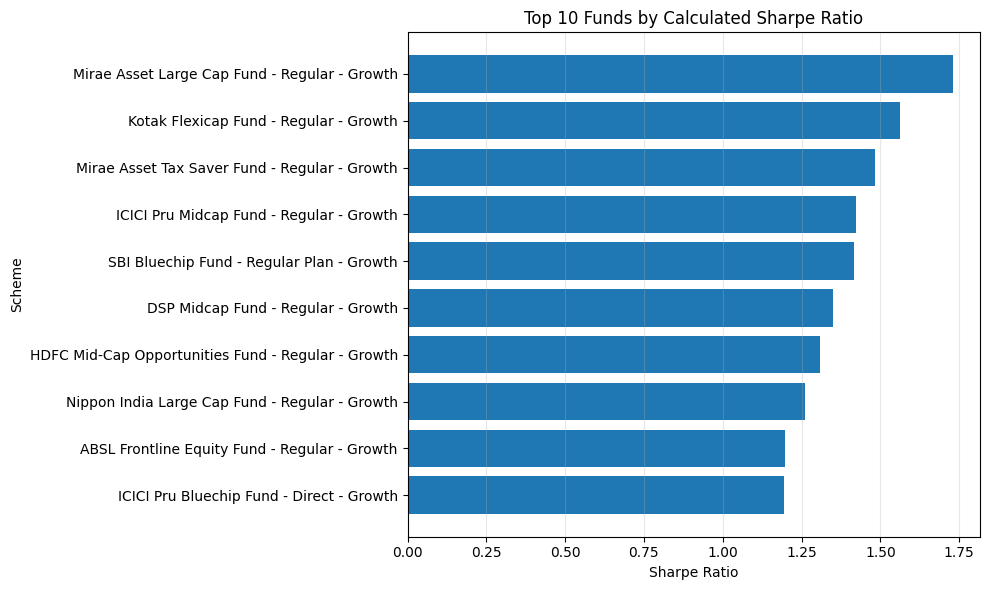

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_sharpe["scheme_name"],
    top10_sharpe["calculated_sharpe"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds by Calculated Sharpe Ratio")

plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

Observation:

• Sharpe Ratio was calculated using Annualized Return, Annualized Volatility, and a 6.5% Risk-Free Rate.
• Funds with higher Sharpe Ratios generated better returns for each unit of risk taken.
• The ranking highlights funds that efficiently balanced return and volatility.
• Comparison with the provided dataset helps validate the implementation and identify any methodological differences.

Business Insight:

Sharpe Ratio is one of the most widely used measures of risk-adjusted performance. Investors can use it to compare funds that have different levels of volatility and identify investments that provide better returns relative to the risk undertaken.

I calculated the Sharpe Ratio using the standard formula: (Annualized Return − Risk-Free Rate) divided by Annualized Volatility. A higher Sharpe Ratio indicates that a fund is generating more return for each unit of risk, making it a key metric for evaluating investment efficiency.

In [ ]:
downside_return = nav_history.copy()

downside_return["downside_return"] = downside_return[
    "daily_return"
].where(
    downside_return["daily_return"] < 0,
    0
)

downside_return.head()

,amfi_code,date,nav,daily_return,downside_return
5750,100016,2022-01-03,520.4608,NaN,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,-0.001210


In [ ]:
downside_dev = (
    downside_return
    .groupby("amfi_code")["downside_return"]
    .std()
    * np.sqrt(252)
    * 100
)

downside_dev = downside_dev.reset_index()
downside_dev.columns = [
    "amfi_code",
    "downside_deviation_pct"
]

downside_dev.head()

,amfi_code,downside_deviation_pct
0,100016,8.194071
1,100025,2.192931
2,100033,10.524836
3,101206,7.917612
4,101207,14.690394


In [ ]:
sortino_df = annual_return.merge(
    downside_dev,
    on="amfi_code"
)

sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sortino_df.head()

,amfi_code,annualized_return_pct,scheme_name_x,downside_deviation_pct,scheme_name_y
0,100016,3.632469,HDFC Top 100 Fund - Regular Plan - Growth,8.194071,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.378122,HDFC Short Term Debt Fund - Regular - Growth,2.192931,HDFC Short Term Debt Fund - Regular - Growth
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,10.524836,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth,7.917612,ABSL Frontline Equity Fund - Regular - Growth
4,101207,11.286684,ABSL Small Cap Fund - Regular - Growth,14.690394,ABSL Small Cap Fund - Regular - Growth


In [ ]:
risk_free_rate = 6.5

sortino_df["calculated_sortino"] = (
    (
        sortino_df["annualized_return_pct"]
        - risk_free_rate
    )
    /
    sortino_df["downside_deviation_pct"]
)

In [ ]:
sortino_df = sortino_df.merge(
    performance[
        ["amfi_code","sortino_ratio"]
    ],
    on="amfi_code",
    how="left"
)

sortino_df["difference"] = (
    sortino_df["calculated_sortino"]
    -
    sortino_df["sortino_ratio"]
).abs()

sortino_df.head()

,amfi_code,annualized_return_pct,scheme_name_x,downside_deviation_pct,scheme_name_y,calculated_sortino,sortino_ratio,difference
0,100016,3.632469,HDFC Top 100 Fund - Regular Plan - Growth,8.194071,HDFC Top 100 Fund - Regular Plan - Growth,-0.349952,1.70,2.049952
1,100025,4.378122,HDFC Short Term Debt Fund - Regular - Growth,2.192931,HDFC Short Term Debt Fund - Regular - Growth,-0.967599,2.79,3.757599
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,10.524836,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2.351955,1.44,0.911955
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth,7.917612,ABSL Frontline Equity Fund - Regular - Growth,2.201555,1.25,0.951555
4,101207,11.286684,ABSL Small Cap Fund - Regular - Growth,14.690394,ABSL Small Cap Fund - Regular - Growth,0.325838,1.47,1.144162


In [ ]:
top10_sortino = (
    sortino_df
    .sort_values(
        "calculated_sortino",
        ascending=False
    )
    .head(10)
)

top10_sortino

,amfi_code,annualized_return_pct,scheme_name_x,downside_deviation_pct,scheme_name_y,calculated_sortino,sortino_ratio,difference
27,120507,6.976545,ICICI Pru Liquid Fund - Regular - Growth,0.148713,ICICI Pru Liquid Fund - Regular - Growth,3.204460,10.37,7.165540
34,148567,31.051613,Mirae Asset Large Cap Fund - Regular - Growth,7.874400,Mirae Asset Large Cap Fund - Regular - Growth,3.117903,1.66,1.457903
30,120843,31.318423,Kotak Flexicap Fund - Regular - Growth,8.423712,Kotak Flexicap Fund - Regular - Growth,2.946257,1.57,1.376257
36,148569,32.724124,Mirae Asset Tax Saver Fund - Regular - Growth,9.578421,Mirae Asset Tax Saver Fund - Regular - Growth,2.737834,1.03,1.707834
19,119551,25.976767,SBI Bluechip Fund - Regular Plan - Growth,7.399320,SBI Bluechip Fund - Regular Plan - Growth,2.632237,1.29,1.342237
25,120505,33.974986,ICICI Pru Midcap Fund - Regular - Growth,10.544681,ICICI Pru Midcap Fund - Regular - Growth,2.605578,1.45,1.155578
38,149323,30.443234,DSP Midcap Fund - Regular - Growth,9.983443,DSP Midcap Fund - Regular - Growth,2.398294,1.50,0.898294
2,100033,31.253944,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,10.524836,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2.351955,1.44,0.911955
9,118632,24.351579,Nippon India Large Cap Fund - Regular - Growth,7.798111,Nippon India Large Cap Fund - Regular - Growth,2.289218,1.68,0.609218
3,101206,23.931060,ABSL Frontline Equity Fund - Regular - Growth,7.917612,ABSL Frontline Equity Fund - Regular - Growth,2.201555,1.25,0.951555


In [ ]:
top10_sortino.columns

Index(['amfi_code', 'annualized_return_pct', 'scheme_name_x',
       'downside_deviation_pct', 'scheme_name_y', 'calculated_sortino',
       'sortino_ratio', 'difference'],
      dtype='object')

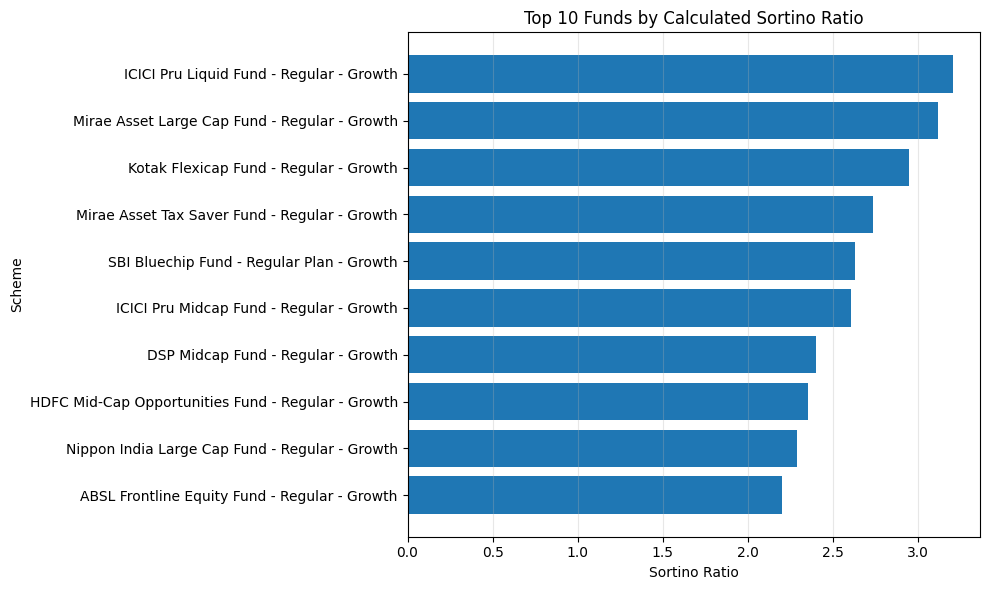

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_sortino["scheme_name_x"],
    top10_sortino["calculated_sortino"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds by Calculated Sortino Ratio")

plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

Observation:

• Sortino Ratio was calculated using annualized return, a 6.5% risk-free rate, and downside deviation.
• Funds with higher Sortino Ratios generated superior returns while effectively limiting downside risk.
• Compared to Sharpe Ratio, Sortino Ratio provides a more focused assessment by considering only negative return volatility.
• The highest-ranked funds demonstrated strong risk-adjusted performance with relatively lower downside fluctuations.

Business Insight:

Sortino Ratio is particularly useful for long-term investors because it penalizes only harmful downside volatility instead of total volatility. It enables better identification of funds that consistently generate returns while minimizing negative market movements.

I calculated the Sortino Ratio by dividing excess annualized return over the risk-free rate by the annualized downside deviation. Unlike the Sharpe Ratio, it considers only negative return volatility, making it a more accurate measure of downside risk-adjusted performance.

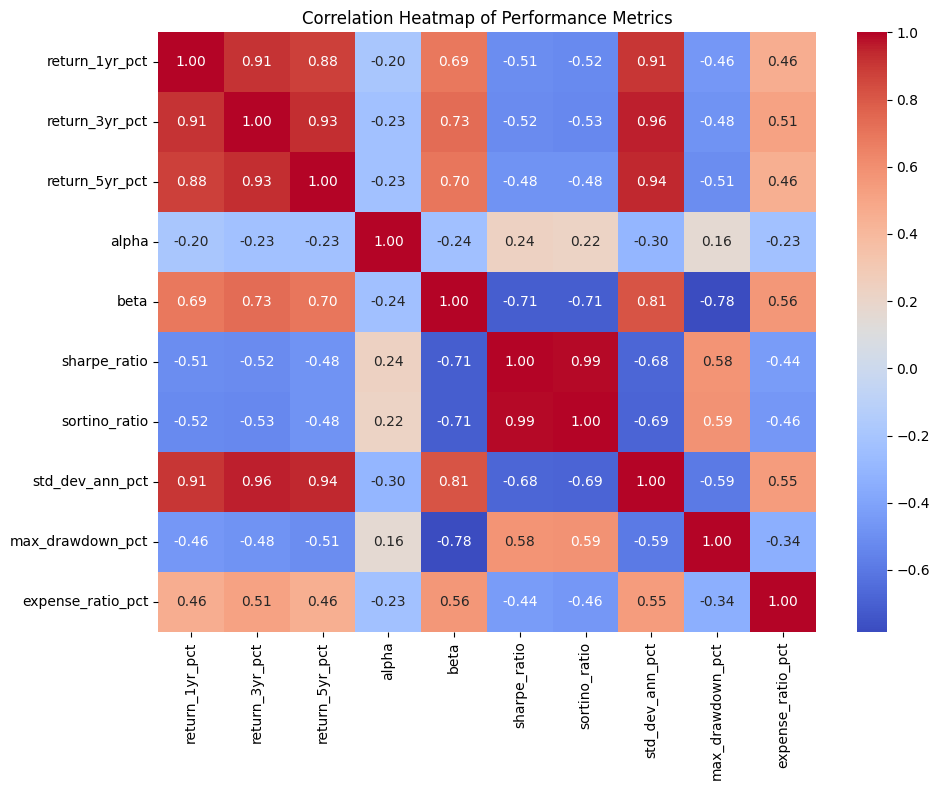

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "sortino_ratio",
    "std_dev_ann_pct",
    "max_drawdown_pct",
    "expense_ratio_pct"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    performance[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Performance Metrics")

plt.tight_layout()
plt.show()

Observation:
- 1-year, 3-year, and 5-year returns are positively correlated with each other.
- Sharpe Ratio and Sortino Ratio show a strong positive relationship.
- Higher annual volatility is generally associated with larger drawdowns.
- Expense Ratio has a relatively weak correlation with fund returns.

Business Insight:
Correlation analysis helps identify relationships among performance metrics. Fund managers can use these insights to understand which factors drive long-term performance and build more balanced investment portfolios.

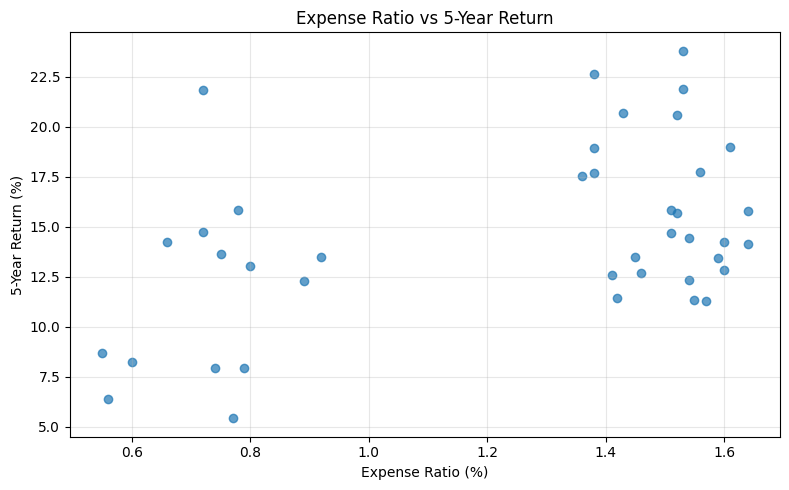

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    performance["expense_ratio_pct"],
    performance["return_5yr_pct"],
    alpha=0.7
)

plt.title("Expense Ratio vs 5-Year Return")

plt.xlabel("Expense Ratio (%)")
plt.ylabel("5-Year Return (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Observation:
- No strong linear relationship is observed between expense ratio and 5-year return.
- Some high-return funds have moderate expense ratios.
- Higher expense does not necessarily result in better fund performance.

Business Insight:
Investors should not select mutual funds based solely on expense ratio. Evaluating returns together with risk-adjusted performance provides a more reliable basis for investment decisions.

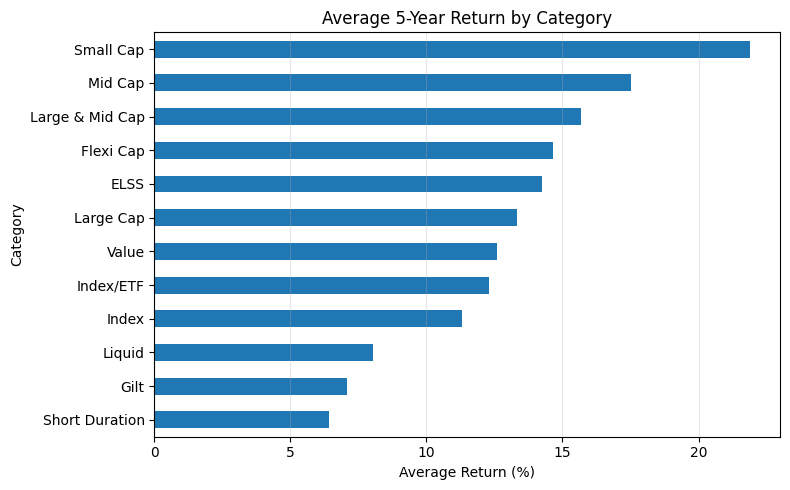

In [ ]:
plt.figure(figsize=(8,5))

performance.groupby("category")["return_5yr_pct"] \
    .mean() \
    .sort_values() \
    .plot(kind="barh")

plt.title("Average 5-Year Return by Category")

plt.xlabel("Average Return (%)")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Observation:
- Average 5-year returns differ across mutual fund categories.
- Equity-oriented categories generally achieve higher average long-term returns.
- Conservative categories show relatively lower average returns with lower risk.

Business Insight:
Category-level performance comparison helps investors select funds based on their return expectations and risk tolerance. AMCs can also identify high-performing categories for product positioning and marketing.